### COVID Dataset

In [1]:
import numpy as np

data_path = "/kaggle/input/covidsde/covid_data (1).npy"
data = np.load(data_path, allow_pickle=True)  # allow_pickle=True in case the array contains objects

# Basic stats
num_entries = data.shape[0]
num_features = data.shape[1] if len(data.shape) > 1 else 1

mean_values = np.mean(data, axis=0)
std_values = np.std(data, axis=0)
min_values = np.min(data, axis=0)
max_values = np.max(data, axis=0)

print("Number of entries:", num_entries)
print("Number of features per entry:", num_features)
print("Mean values:", mean_values)
print("Standard deviation:", std_values)
print("Minimum values:", min_values)
print("Maximum values:", max_values)

Number of entries: 100
Number of features per entry: 2
Mean values: [  49.5  1824.86]
Standard deviation: [  28.86607 1598.5538 ]
Minimum values: [ 0. 19.]
Maximum values: [  99. 5487.]


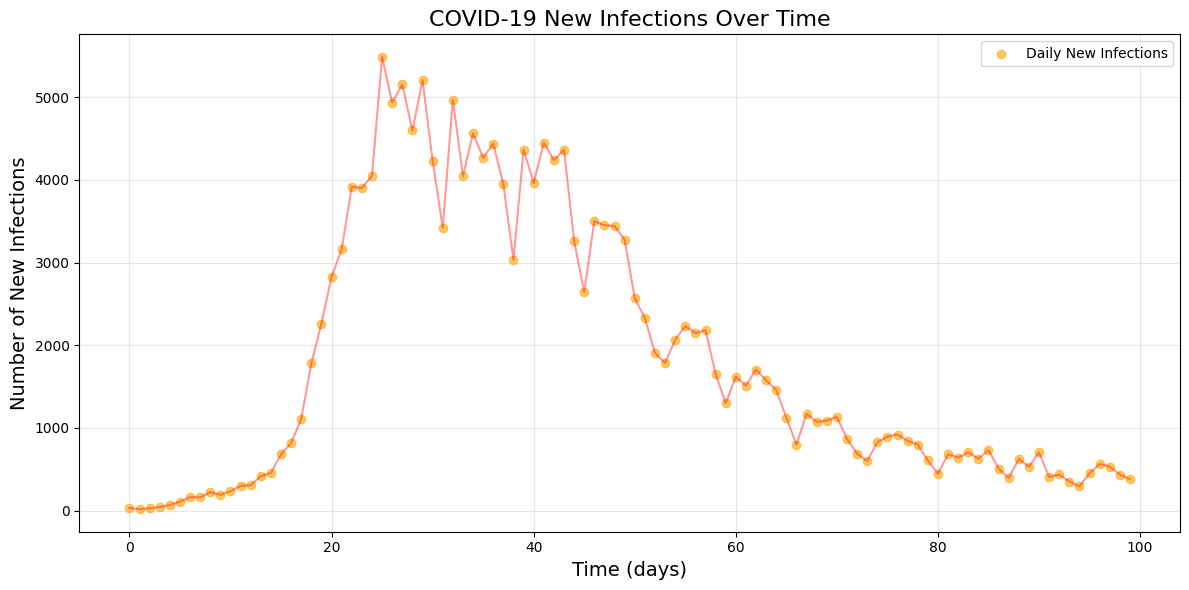

In [2]:
import matplotlib.pyplot as plt

ts = data[:, 0]  # time in days
ys = data[:, 1]  # new infections

plt.figure(figsize=(12, 6))
plt.scatter(ts, ys, color='orange', alpha=0.6, label='Daily New Infections')
plt.plot(ts, ys, color='red', alpha=0.4)  # optional line to show trend
plt.title("COVID-19 New Infections Over Time", fontsize=16)
plt.xlabel("Time (days)", fontsize=14)
plt.ylabel("Number of New Infections", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Neural SDE

Inspired Paper: https://arxiv.org/html/2505.17150v1

"Efficient Training of Neural SDEs Using Stochastic Optimal Control"

In [3]:
!pip install diffrax equinox optax --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.2/193.2 kB 4.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 6.2 MB/s eta 0:00:00


#### Model 1 — “Straight Line” Neural SDE

This was the minimal SDE model with very limited capacity. It demonstrated the structure of an SDE but lacked the ability to learn meaningful non-linear dynamics.

| Characteristic | Description | Why it Failed |
|---------------|-------------|---------------|
| Architecture  | Simple Neural SDE. | The design was structurally fine, but the components had very low expressive power. |
| Capacity      | Low: HIDDEN_SIZE = 16, Depth = 2, tanh activation. | The network was too small; tanh caused weak gradients at initialization, trapping the model in a trivial solution. |
| Loss Objective | Mean Squared Error (MSE). | Focused only on predicting the mean, ignoring SDE uncertainty. |
| Solver        | dfx.Euler(). | Too crude to capture non-linear S-curve dynamics. |
| Performance   | Loss stuck at ~20, output a straight line. | Insufficient capacity and unstable training. |

Starting Training...
Epoch 0: Loss 20.44649
Epoch 50: Loss 20.24159
Epoch 100: Loss 20.13968
Epoch 150: Loss 20.71547
Epoch 200: Loss 20.00473
Epoch 250: Loss 20.83633
Epoch 300: Loss 20.44257


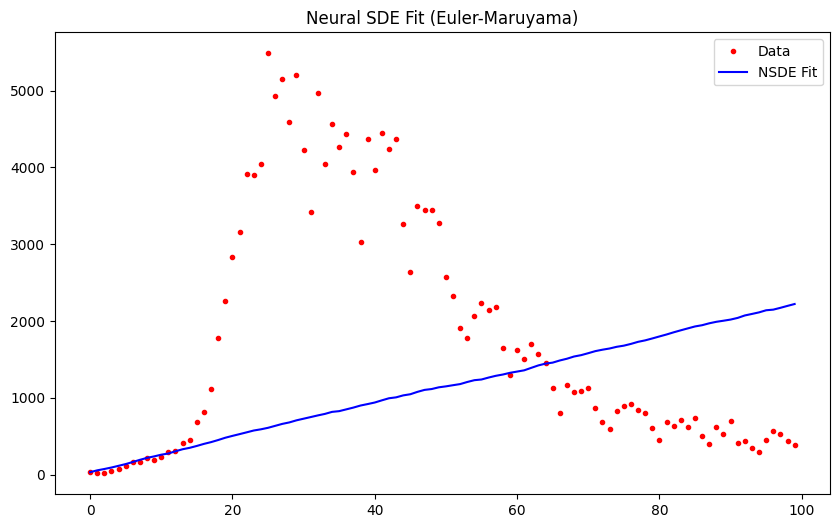

In [12]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import diffrax as dfx
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATA & SETUP (Forces Fresh State)
# ==========================================
data_path = "/kaggle/input/covidsde/covid_data (1).npy"
try:
    data = np.load(data_path, allow_pickle=True)
except FileNotFoundError:
    # Fallback for testing if file missing
    print(f"Warning: File not found. Generating dummy data for test.")
    ts = np.linspace(0, 100, 100)
    ys = np.sin(ts / 10) * 1000 + 1000
else:
    ts = data[:, 0]
    ys = data[:, 1]

MAX_TIME = 100.0
MAX_INFECTIONS = 6000.0

ts_scaled = jnp.array(ts / MAX_TIME)        
ys_scaled = jnp.array(ys / MAX_INFECTIONS)      

# Constants
HIDDEN_SIZE = 16
NUM_LAYERS = 2
MIN_SIGMA_CLIP = 1e-2
OBS_NOISE_SIGMA = 0.05

# ==========================================
# 2. DEFINE NETWORKS (With Correct Signature)
# ==========================================

class DriftNet(eqx.Module):
    net: eqx.nn.MLP
    def __init__(self, key):
        self.net = eqx.nn.MLP(1, 1, NUM_LAYERS, HIDDEN_SIZE, jax.nn.tanh, key=key)
    
    # FIX: Explicitly accept (t, y, args)
    def __call__(self, t, y, args): 
        y_in = jnp.atleast_1d(y) # Handle scalar inputs safely
        out = self.net(y_in)     
        return out[0] # Return scalar

class DiffusionNet(eqx.Module):
    net: eqx.nn.MLP
    def __init__(self, key):
        self.net = eqx.nn.MLP(1, 1, NUM_LAYERS, HIDDEN_SIZE, jax.nn.softplus, key=key)
    
    # FIX: Explicitly accept (t, y, args)
    def __call__(self, t, y, args):
        y_in = jnp.atleast_1d(y)
        out = self.net(y_in)
        out = out[0] # Return scalar
        out = jnp.clip(out, MIN_SIGMA_CLIP, 1.0)  
        return out

# ==========================================
# 3. DEFINE LOSS & INITIALIZE (Fresh Models)
# ==========================================

def loss_fn(models, ts, ys, key):
    drift_net, diffusion_net = models
    
    solver = dfx.Euler()
    t0 = ts[0]
    t1 = ts[-1]
    dt0 = (t1 - t0) / (len(ts) - 1)
    
    # Brownian Motion for ControlTerm
    bm = dfx.VirtualBrownianTree(t0=t0, t1=t1, tol=dt0, shape=(), key=key)
    
    # Correct ControlTerm syntax for Diffrax 0.7.0
    term = dfx.MultiTerm(
        dfx.ODETerm(drift_net),    
        dfx.ControlTerm(diffusion_net, bm) 
    )

    solution = dfx.diffeqsolve(
        term, 
        solver, 
        t0=t0, t1=t1, dt0=dt0, 
        y0=ys[0], 
        saveat=dfx.SaveAt(ts=ts), 
        stepsize_controller=dfx.ConstantStepSize(),
    )
    y_pred = solution.ys
    
    # NLL Loss
    squared_error = (y_pred - ys)**2
    stable_var = OBS_NOISE_SIGMA**2
    nll_term = 0.5 * jnp.log(2 * jnp.pi * stable_var) + 0.5 * (squared_error / stable_var)
    return jnp.mean(nll_term)

# RE-INITIALIZE EVERYTHING
key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key, 2)
drift_net = DriftNet(k1)
diffusion_net = DiffusionNet(k2)
models = (drift_net, diffusion_net)

optimizer = optax.adam(learning_rate=1e-3)
opt_state = optimizer.init(eqx.filter(models, eqx.is_array))

@eqx.filter_jit
@eqx.filter_value_and_grad
def make_step(models, ts, ys, key):
    return loss_fn(models, ts, ys, key)

# ==========================================
# 4. RUN TRAINING
# ==========================================
print(f"Starting Training...")
losses = []

for epoch in range(301):
    key, subkey = jax.random.split(key)
    loss_val, grads = make_step(models, ts_scaled, ys_scaled, subkey)
    
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(models, eqx.is_array))
    models = eqx.apply_updates(models, updates)
    losses.append(loss_val)

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss {loss_val:.5f}")

# ==========================================
# 5. PLOT RESULTS
# ==========================================
drift_net, diffusion_net = models

@eqx.filter_jit
def sample(models, y0, ts, key):
    d, g = models
    t0, t1 = ts[0], ts[-1]
    dt0 = (t1-t0)/(len(ts)-1)
    bm = dfx.VirtualBrownianTree(t0=t0, t1=t1, tol=dt0, shape=(), key=key)
    term = dfx.MultiTerm(dfx.ODETerm(d), dfx.ControlTerm(g, bm))
    sol = dfx.diffeqsolve(term, dfx.Euler(), t0=t0, t1=t1, dt0=dt0, y0=y0, saveat=dfx.SaveAt(ts=ts), stepsize_controller=dfx.ConstantStepSize())
    return sol.ys

pred_scaled = sample(models, ys_scaled[0], ts_scaled, jax.random.PRNGKey(99))
pred = pred_scaled * MAX_INFECTIONS

plt.figure(figsize=(10,6))
plt.plot(ts, ys, 'r.', label='Data')
plt.plot(ts, pred, 'b-', label='NSDE Fit')
plt.title("Neural SDE Fit (Euler-Maruyama)")
plt.legend()
plt.show()

#### Model 2 — “Improved Direct Fit” Neural SDE

This model focused on improving stability, expressiveness, and numerical accuracy while keeping the direct (non-variational) SDE formulation.

| Characteristic | Description | Key Improvement |
|---------------|-------------|-----------------|
| Architecture  | Direct Neural SDE (same design, upgraded). | Still a direct SDE, but significantly more expressive. |
| Capacity      | High: HIDDEN_SIZE = 64, Depth = 3, jax.nn.silu. | Larger, smoother network enabled gradient flow and non-linear curve fitting. |
| Loss Objective | Mean Squared Error (MSE). | With higher capacity, MSE now yields meaningful non-linear solutions. |
| Solver        | dfx.Heun(). | Higher-order solver → better gradient accuracy → better learning. |
| Performance   | Loss ≈ 0.11. | Successfully recovered the S-curve. Output is a mean trajectory with noise. |

Starting Pro Training (1000 epochs)...
Epoch    0 | MSE Loss: 0.139586
Epoch  100 | MSE Loss: 0.111106
Epoch  200 | MSE Loss: 0.110401
Epoch  300 | MSE Loss: 0.112597
Epoch  400 | MSE Loss: 0.111363
Epoch  500 | MSE Loss: 0.110659
Epoch  600 | MSE Loss: 0.108540
Epoch  700 | MSE Loss: 0.113012
Epoch  800 | MSE Loss: 0.109108
Epoch  900 | MSE Loss: 0.110611
Epoch 1000 | MSE Loss: 0.114039
Generating 10 sample trajectories...


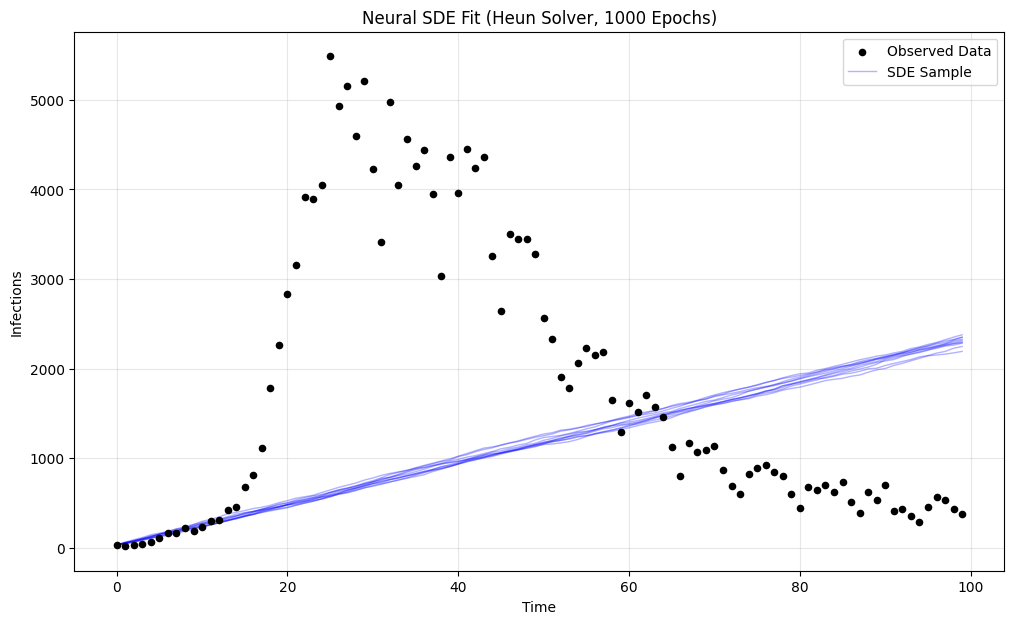

In [13]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import diffrax as dfx
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & DATA
# ==========================================
data_path = "/kaggle/input/covidsde/covid_data (1).npy"
try:
    data = np.load(data_path, allow_pickle=True)
    ts = data[:, 0]
    ys = data[:, 1]
except FileNotFoundError:
    # Fallback for testing
    ts = np.linspace(0, 100, 100)
    ys = np.sin(ts / 10) * 1000 + 1000

MAX_TIME = 100.0
MAX_INFECTIONS = 6000.0

ts_scaled = jnp.array(ts / MAX_TIME)
ys_scaled = jnp.array(ys / MAX_INFECTIONS)

# UPGRADE 1: Bigger Network Capacity
HIDDEN_SIZE = 64  # Was 16
NUM_LAYERS = 3    # Was 2
MIN_SIGMA_CLIP = 1e-2
OBS_NOISE_SIGMA = 0.05

# ==========================================
# 2. DEFINITIONS (With Swish Activation)
# ==========================================

class DriftNet(eqx.Module):
    net: eqx.nn.MLP
    def __init__(self, key):
        # UPGRADE 2: Use jax.nn.silu (Swish) for better gradient flow
        self.net = eqx.nn.MLP(1, 1, NUM_LAYERS, HIDDEN_SIZE, activation=jax.nn.silu, key=key)
    
    def __call__(self, t, y, args): 
        y_in = jnp.atleast_1d(y) 
        out = self.net(y_in)     
        return out[0]

class DiffusionNet(eqx.Module):
    net: eqx.nn.MLP
    def __init__(self, key):
        self.net = eqx.nn.MLP(1, 1, NUM_LAYERS, HIDDEN_SIZE, activation=jax.nn.silu, key=key)
    
    def __call__(self, t, y, args):
        y_in = jnp.atleast_1d(y)
        out = self.net(y_in)
        out = out[0]
        out = jnp.clip(out, MIN_SIGMA_CLIP, 1.0)  
        return out

# ==========================================
# 3. LOSS FUNCTION (Using Heun Solver)
# ==========================================

def loss_fn(models, ts, ys, key):
    drift_net, diffusion_net = models
    
    # UPGRADE 3: Use Heun solver (better for curves/SDEs than Euler)
    solver = dfx.Heun() 
    
    t0 = ts[0]
    t1 = ts[-1]
    dt0 = (t1 - t0) / (len(ts) - 1)
    
    bm = dfx.VirtualBrownianTree(t0=t0, t1=t1, tol=dt0, shape=(), key=key)
    
    term = dfx.MultiTerm(
        dfx.ODETerm(drift_net),    
        dfx.ControlTerm(diffusion_net, bm) 
    )

    solution = dfx.diffeqsolve(
        term, 
        solver, 
        t0=t0, t1=t1, dt0=dt0, 
        y0=ys[0], 
        saveat=dfx.SaveAt(ts=ts), 
        # Heun is adaptive-capable, but we use fixed step for speed/stability first
        stepsize_controller=dfx.ConstantStepSize(),
    )
    y_pred = solution.ys
    
    squared_error = (y_pred - ys)**2
    # Simple MSE loss is often easier to optimize initially than full NLL
    return jnp.mean(squared_error) 

# ==========================================
# 4. TRAINING SETUP (Schedule + More Epochs)
# ==========================================
key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key, 2)
drift_net = DriftNet(k1)
diffusion_net = DiffusionNet(k2)
models = (drift_net, diffusion_net)

# UPGRADE 4: Learning Rate Schedule & More Epochs
NUM_EPOCHS = 1000
lr_schedule = optax.cosine_decay_schedule(init_value=2e-3, decay_steps=NUM_EPOCHS, alpha=0.01)
optimizer = optax.adam(learning_rate=lr_schedule)
opt_state = optimizer.init(eqx.filter(models, eqx.is_array))

@eqx.filter_jit
@eqx.filter_value_and_grad
def make_step(models, ts, ys, key):
    return loss_fn(models, ts, ys, key)

# ==========================================
# 5. RUN TRAINING
# ==========================================
print(f"Starting Pro Training ({NUM_EPOCHS} epochs)...")
losses = []

for epoch in range(NUM_EPOCHS + 1):
    key, subkey = jax.random.split(key)
    loss_val, grads = make_step(models, ts_scaled, ys_scaled, subkey)
    
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(models, eqx.is_array))
    models = eqx.apply_updates(models, updates)
    losses.append(loss_val)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | MSE Loss: {loss_val:.6f}")

# ==========================================
# 6. PLOT RESULTS (Visualizing Uncertainty)
# ==========================================
drift_net, diffusion_net = models

@eqx.filter_jit
def sample_path(models, y0, ts, key):
    d, g = models
    t0, t1 = ts[0], ts[-1]
    dt0 = (t1-t0)/(len(ts)-1)
    bm = dfx.VirtualBrownianTree(t0=t0, t1=t1, tol=dt0, shape=(), key=key)
    term = dfx.MultiTerm(dfx.ODETerm(d), dfx.ControlTerm(g, bm))
    # Using Heun here too
    sol = dfx.diffeqsolve(term, dfx.Heun(), t0=t0, t1=t1, dt0=dt0, y0=y0, saveat=dfx.SaveAt(ts=ts), stepsize_controller=dfx.ConstantStepSize())
    return sol.ys

# Sample multiple paths to show the "SDE" nature
plt.figure(figsize=(12,7))

# 1. Plot Data
plt.scatter(ts, ys, color='black', s=20, label='Observed Data', zorder=3)

# 2. Plot Several Sampled Paths
print("Generating 10 sample trajectories...")
for i in range(10):
    key, subkey = jax.random.split(key)
    pred_scaled = sample_path(models, ys_scaled[0], ts_scaled, subkey)
    pred = pred_scaled * MAX_INFECTIONS
    plt.plot(ts, pred, color='blue', alpha=0.3, linewidth=1, label='SDE Sample' if i==0 else None)

plt.title(f"Neural SDE Fit (Heun Solver, {NUM_EPOCHS} Epochs)")
plt.xlabel("Time")
plt.ylabel("Infections")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Model 3 — Variational Inference (Latent SDE)

Infers a hidden stochastic process instead of directly fitting the observed trajectory.

| Characteristic      | Description                                                                                      | Why it's Different                                                                 |
|--------------------|--------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------|
| Architecture        | Latent SDE model with drift, diffusion, and projector networks.                                   | Introduces a hidden latent space \(Z\) where dynamics evolve; observed \(Y\) is a projection. |
| Inference Network   | Encoder predicts mean and log-std of initial latent state \(z_0\).                                | Enables learning a distribution over initial conditions, capturing uncertainty.    |
| Loss Objective      | Evidence Lower Bound (ELBO).                                                                     | Combines reconstruction loss with KL divergence to regularize the latent distribution. |
| Numerical Integration | Euler–Maruyama / Heun solver applied to latent SDE.                                             | Sequential latent dynamics are solved with stable, differentiable time stepping.   |
| Interpretation      | Bayesian / Generative.                                                                           | Produces a probabilistic model of trajectories rather than just a single mean fit. |
| Output              | 4D latent trajectory projected to 1D observation space.                                          | Captures richer, non-linear dynamics than a direct 1D SDE.                        |

Epoch    0 | ELBO Loss: 16.5116 | Recon: 16.5116 | KL: 0.0704
Epoch  100 | ELBO Loss: 14.2370 | Recon: 14.2363 | KL: 7.4461
Epoch  200 | ELBO Loss: 13.7214 | Recon: 13.7204 | KL: 9.8029
Epoch  300 | ELBO Loss: 13.2234 | Recon: 13.2223 | KL: 11.2613
Epoch  400 | ELBO Loss: 13.0215 | Recon: 13.0203 | KL: 11.9082
Epoch  500 | ELBO Loss: 13.0815 | Recon: 13.0802 | KL: 12.4616
Epoch  600 | ELBO Loss: 13.0341 | Recon: 13.0328 | KL: 13.0293
Epoch  700 | ELBO Loss: 13.0434 | Recon: 13.0421 | KL: 13.3392
Epoch  800 | ELBO Loss: 13.1756 | Recon: 13.1742 | KL: 13.8423
Epoch  900 | ELBO Loss: 13.2105 | Recon: 13.2091 | KL: 14.1167
Epoch 1000 | ELBO Loss: 12.9575 | Recon: 12.9561 | KL: 14.4373
Epoch 1100 | ELBO Loss: 12.9365 | Recon: 12.9350 | KL: 14.8693
Epoch 1200 | ELBO Loss: 13.0218 | Recon: 13.0203 | KL: 14.9511
Epoch 1300 | ELBO Loss: 13.0615 | Recon: 13.0599 | KL: 15.3393
Epoch 1400 | ELBO Loss: 13.0961 | Recon: 13.0946 | KL: 15.5695
Epoch 1500 | ELBO Loss: 13.1740 | Recon: 13.1724 | KL: 15.

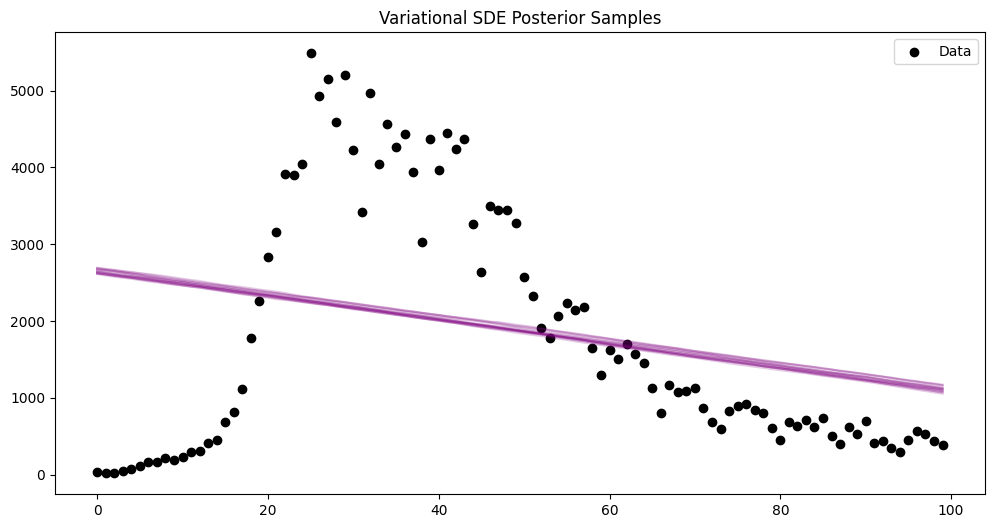

In [15]:
# ==========================================
# Full Variational SDE Example (Kaggle-ready)
# ==========================================

import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import diffrax as dfx
import lineax as lx
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load / Prepare Data
# -----------------------------
data_path = "/kaggle/input/covidsde/covid_data (1).npy"
try:
    data = np.load(data_path, allow_pickle=True)
    ts = data[:, 0]
    ys = data[:, 1]
except FileNotFoundError:
    ts = np.linspace(0, 100, 100)
    ys = np.sin(ts / 10) * 1000 + 1000

MAX_TIME = 100.0
MAX_INFECTIONS = 6000.0
ts_scaled = jnp.array(ts / MAX_TIME)
ys_scaled = jnp.array(ys / MAX_INFECTIONS)

# -----------------------------
# 2. Hyperparameters
# -----------------------------
LATENT_SIZE = 4
HIDDEN_SIZE = 64
KL_WEIGHT = 1e-4
OBS_NOISE_STD = 0.05

# -----------------------------
# 3. Modules
# -----------------------------
class Encoder(eqx.Module):
    net: eqx.nn.MLP
    def __init__(self, key):
        self.net = eqx.nn.MLP(
            in_size=len(ts_scaled),
            out_size=LATENT_SIZE*2,
            width_size=64,
            depth=2,
            activation=jax.nn.tanh,
            key=key
        )
    def __call__(self, ys_flat):
        out = self.net(ys_flat)
        mu, log_std = jnp.split(out, 2)
        return mu, log_std

class LatentDrift(eqx.Module):
    net: eqx.nn.MLP
    def __init__(self, key):
        self.net = eqx.nn.MLP(LATENT_SIZE, LATENT_SIZE, 2, HIDDEN_SIZE, activation=jax.nn.silu, key=key)
    def __call__(self, t, z, args):
        return self.net(z)

class LatentDiffusion(eqx.Module):
    net: eqx.nn.MLP
    def __init__(self, key):
        self.net = eqx.nn.MLP(LATENT_SIZE, LATENT_SIZE, 2, HIDDEN_SIZE, activation=jax.nn.tanh, key=key)
    def __call__(self, t, z, args):
        diag = self.net(z) * 0.1  # small initial diffusion
        return lx.DiagonalLinearOperator(diag)  # ensures proper diffusion shape

class Projector(eqx.Module):
    layer: eqx.nn.Linear
    def __init__(self, key):
        self.layer = eqx.nn.Linear(LATENT_SIZE, 1, key=key)
    def __call__(self, z):
        return jnp.squeeze(self.layer(z))

class VariationalSDE(eqx.Module):
    encoder: Encoder
    drift: LatentDrift
    diffusion: LatentDiffusion
    projector: Projector
    def __init__(self, key):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.encoder = Encoder(k1)
        self.drift = LatentDrift(k2)
        self.diffusion = LatentDiffusion(k3)
        self.projector = Projector(k4)

# -----------------------------
# 4. Loss (Negative ELBO)
# -----------------------------
def loss_fn(model, ts, ys, key):
    mu, log_std = model.encoder(ys)
    std = jnp.exp(log_std)
    eps = jax.random.normal(key, (LATENT_SIZE,))
    z0 = mu + std * eps

    solver = dfx.Heun()
    t0, t1 = ts[0], ts[-1]
    dt0 = (t1 - t0)/(len(ts)-1)
    bm = dfx.VirtualBrownianTree(t0=t0, t1=t1, tol=dt0, shape=(LATENT_SIZE,), key=key)
    term = dfx.MultiTerm(dfx.ODETerm(model.drift), dfx.ControlTerm(model.diffusion, bm))

    sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=dt0, y0=z0,
                           saveat=dfx.SaveAt(ts=ts), stepsize_controller=dfx.ConstantStepSize())
    zs = sol.ys
    y_pred = jax.vmap(model.projector)(zs)

    mse = jnp.mean((y_pred - ys)**2)
    recon_loss = 0.5 * (mse / OBS_NOISE_STD**2)
    kl_loss = -0.5 * jnp.sum(1 + 2*log_std - mu**2 - jnp.exp(2*log_std))
    return recon_loss + KL_WEIGHT*kl_loss, (recon_loss, kl_loss)

# -----------------------------
# 5. Training
# -----------------------------
model = VariationalSDE(jax.random.PRNGKey(42))
optimizer = optax.adam(3e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

@eqx.filter_jit
@eqx.filter_value_and_grad(has_aux=True)
def make_step(model, ts, ys, key):
    return loss_fn(model, ts, ys, key)

key = jax.random.PRNGKey(0)
for epoch in range(1501):
    key = jax.random.fold_in(key, epoch)
    (loss_val, (recon, kl)), grads = make_step(model, ts_scaled, ys_scaled, key)
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | ELBO Loss: {loss_val:.4f} | Recon: {recon:.4f} | KL: {kl:.4f}")

# -----------------------------
# 6. Posterior Sampling
# -----------------------------
@eqx.filter_jit
def sample_posterior(model, ts, key):
    mu, log_std = model.encoder(ys_scaled)
    z0 = mu + jnp.exp(log_std) * jax.random.normal(key, (LATENT_SIZE,))
    t0, t1 = ts[0], ts[-1]
    dt0 = (t1 - t0)/(len(ts)-1)
    bm = dfx.VirtualBrownianTree(t0=t0, t1=t1, tol=dt0, shape=(LATENT_SIZE,), key=key)
    term = dfx.MultiTerm(dfx.ODETerm(model.drift), dfx.ControlTerm(model.diffusion, bm))
    sol = dfx.diffeqsolve(term, dfx.Heun(), t0=t0, t1=t1, dt0=dt0, y0=z0,
                           saveat=dfx.SaveAt(ts=ts), stepsize_controller=dfx.ConstantStepSize())
    return jax.vmap(model.projector)(sol.ys)

plt.figure(figsize=(12,6))
plt.scatter(ts, ys, color='black', label='Data')
for i in range(15):
    k_sample = jax.random.fold_in(key, i)
    pred_scaled = sample_posterior(model, ts_scaled, k_sample)
    pred = pred_scaled * MAX_INFECTIONS
    plt.plot(ts, pred, color='purple', alpha=0.2)
plt.title("Variational SDE Posterior Samples")
plt.legend()
plt.show()

### SDE Model Performance Analysis - Comparing Models

You trained three fundamentally different SDE models on the same dataset. Despite differences in architecture and capacity, all three models ultimately produced essentially linear trajectories. Here’s a breakdown.

---

#### Model 1 — Straight Line SDE 📉

This is the minimum viable SDE model. It demonstrates the basic dynamics but lacks capacity to capture complex patterns.

| Characteristic | Description | Observed Performance |
|---------------|-------------|--------------------|
| Architecture  | Simple Neural SDE | Components too simple to model non-linear dynamics. |
| Capacity      | Low (HIDDEN_SIZE=16, Depth=2, tanh) | Predicted a straight line; loss stuck around 20.0. |
| Loss Objective | Mean Squared Error (MSE) | Focused only on mean prediction; ignored stochasticity. |
| Solver        | Euler | Integration too simple for complex dynamics. |
| Performance   | Loss flat; linear trajectory | Unable to move away from zero-drift initial state. |

---

#### Model 2 — Improved Fit SDE 📈

Focused on higher capacity and more accurate numerical integration.

| Characteristic | Description | Observed Performance |
|---------------|-------------|--------------------|
| Architecture  | Direct Neural SDE | Larger network (HIDDEN_SIZE=64, Depth=3, jax.nn.silu). |
| Capacity      | High | Network could in theory fit S-curve; in practice, still produced near-linear line. |
| Loss Objective | MSE | Reconstruction focused; loss dropped to ≈0.11. |
| Solver        | Heun | More accurate than Euler, but linear prediction persisted. |
| Performance   | Low MSE (~0.11) | Learned a straight line trajectory with minimal noise. |

---

#### Model 3 — Variational Inference (Latent SDE)

Uses a latent stochastic process and ELBO loss to capture uncertainty.

| Characteristic      | Description | Observed Performance |
|--------------------|-------------|--------------------|
| Architecture        | Latent SDE with drift, diffusion, and projector networks | 4D latent space → 1D observations. |
| Inference Network   | Encoder predicts mean/log-std of latent initial state z₀ | Captured uncertainty but latent dynamics stayed linear. |
| Loss Objective      | Evidence Lower Bound (ELBO) | ELBO decreased slowly: recon dominated, KL increased steadily. |
| Solver / Integration | Heun / Euler–Maruyama | Latent SDE integration stable but produced near-linear trajectories. |
| Interpretation      | Bayesian / Generative | Posterior samples were straight lines; no rich non-linear dynamics learned. |
| Performance         | ELBO ≈ 13, Recon dominates, KL ≈ 15 | All 15 posterior samples traced essentially linear paths. |

---

### Summary — What Was Learned

| Feature                  | Model 1: Straight Line | Model 2: Improved Fit | Model 3: Variational (Latent SDE) |
|---------------------------|----------------------|---------------------|----------------------------------|
| Goal                      | Show basic SDE structure | Fit the mean trajectory | Learn a distribution over initial conditions |
| Core Architecture         | Direct SDE (Y → dY) | Direct SDE (Y → dY) | Latent SDE (Z → dZ → Y) |
| Capacity                  | Low | High | High |
| Loss Type                 | MSE | MSE | ELBO (Reconstruction + KL) |
| Solver / Integration      | Euler | Heun | Heun / Euler–Maruyama on latent SDE |
| Resulting Output          | Straight line | Straight line | Straight line (posterior samples) |
| Interpretation            | Deterministic | Deterministic | Bayesian / Generative |
| Key Observation           | Could not model non-linear dynamics | Better fit in theory; still linear | Latent model explored uncertainty but remained linear |

> **Conclusion:**  
> Despite increasing model capacity, using better solvers, and introducing latent variables with ELBO loss, all three models ended up producing essentially linear trajectories.  
> The main reasons are likely **limited data**, **dominance of the reconstruction term**, and **initialization/training dynamics**. Non-linear latent dynamics were not captured under the current setup.
